In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim.lr_scheduler import LinearLR
import torch.nn as nn
import torch
import gc
import os
import imageio
import yaml
from torch.optim import Adam
from datetime import datetime
from PIL import Image
import requests

## 2D Gaussian Splatting ##

The core function for generating 2D Gaussian Splatting. The core mechanic of this function is as follow

> Constructs a 2D Gaussian kernel using ~~provided batch of sigma_x, sigma_y, and rho~~ rotation and scale \
(as proposed in the [3D Gaussian Splatting paper](https://repo-sam.inria.fr/fungraph/3d-gaussian-splatting/3d_gaussian_splatting_low.pdf), to constrain the 2D Gaussian to valid covariance matrices we describle the 2D Gaussian in a form of an ellipse with rotation and scale)
\begin{equation} \Sigma = RSS^TR^T \end{equation}


> Normalises and reshapes the kernel to RGB channels, pads to match the image size, and translates based on given coords. Basically poutting the relevant kernel in the relevant coordinate position.


> Multiplies the RGB kernels with given colours, sums up the layers, and returns the final clamped and permuted image.







In [2]:
def generate_2D_gaussian_splatting(kernel_size, scale, rotation, coords, colours, image_size, device="cpu"):
    batch_size = colours.shape[0]

    # Ensure scale and rotation have the correct shape
    scale = scale.view(batch_size, 2)
    rotation = rotation.view(batch_size)

    # Compute the components of the covariance matrix
    cos_rot = torch.cos(rotation)
    sin_rot = torch.sin(rotation)

    R = torch.stack([
        torch.stack([cos_rot, -sin_rot], dim=-1),
        torch.stack([sin_rot, cos_rot], dim=-1)
    ], dim=-2)

    S = torch.diag_embed(scale)

    # Compute covariance matrix: RSS^TR^T
    # covariance = R @ S @ S.transpose(-1, -2) @ R.transpose(-1, -2)
    # since in 2D , SS^T = SS and since transpose potentially could cause memory access issue
    covariance = R @ S @ S @ R.transpose(-1, -2)

    # Compute inverse covariance
    inv_covariance = torch.inverse(covariance)

    # Create the kernel
    x = torch.linspace(-5, 5, kernel_size, device=device)
    y = torch.linspace(-5, 5, kernel_size, device=device)
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    xy = torch.stack([xx, yy], dim=-1).unsqueeze(0).expand(batch_size, -1, -1, -1)

    z = torch.einsum('bxyi,bij,bxyj->bxy', xy, -0.5 * inv_covariance, xy)
    kernel = torch.exp(z) / (2 * torch.tensor(np.pi, device=device) * torch.sqrt(torch.det(covariance))).view(batch_size, 1, 1)

    # Normalize the kernel
    kernel_max = kernel.amax(dim=(-2, -1), keepdim=True)
    kernel_normalized = kernel / kernel_max

    # Reshape the kernel for RGB channels
    kernel_rgb = kernel_normalized.unsqueeze(1).expand(-1, 3, -1, -1)

    # Add padding to match image size
    pad_h = image_size[0] - kernel_size
    pad_w = image_size[1] - kernel_size

    if pad_h < 0 or pad_w < 0:
        raise ValueError("Kernel size should be smaller or equal to the image size.")

    padding = (pad_w // 2, pad_w // 2 + pad_w % 2, pad_h // 2, pad_h // 2 + pad_h % 2)
    kernel_rgb_padded = F.pad(kernel_rgb, padding, "constant", 0)

    # Translate the kernel
    b, c, h, w = kernel_rgb_padded.shape
    theta = torch.zeros(b, 2, 3, dtype=torch.float32, device=device)
    theta[:, 0, 0] = 1.0
    theta[:, 1, 1] = 1.0
    theta[:, :, 2] = coords

    grid = F.affine_grid(theta, size=(b, c, h, w), align_corners=True)
    kernel_rgb_padded_translated = F.grid_sample(kernel_rgb_padded, grid, align_corners=True)

    # Apply colors and sum the layers
    rgb_values_reshaped = colours.unsqueeze(-1).unsqueeze(-1)
    final_image_layers = rgb_values_reshaped * kernel_rgb_padded_translated
    final_image = final_image_layers.sum(dim=0)
    final_image = torch.clamp(final_image, 0, 1)
    final_image = final_image.permute(1, 2, 0)

    return final_image

# Example usage

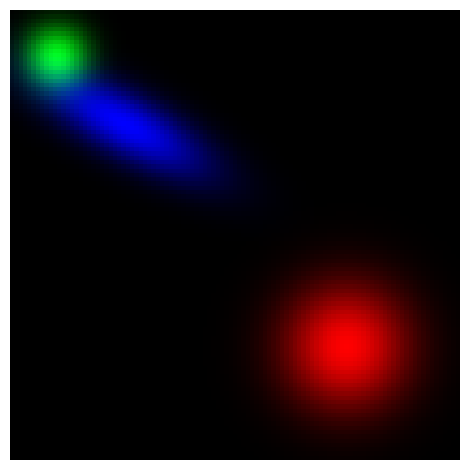

In [3]:
device = "cpu"
kernel_size = 101  # You can adjust the kernel size as needed

scale_x = torch.tensor([1.0, 0.5, 0.5], device=device)
scale_y = torch.tensor([1.0, 0.5, 1.5], device=device)
scale = torch.stack([scale_x, scale_y], dim=-1)
rotation = torch.tensor([0.0, 0.0, -0.5], device=device) # a value between -pi/2 and pi/2
vectors = torch.tensor([(-0.5, -0.5), (0.8, 0.8), (0.5, 0.5)], device=device)
colours = torch.tensor([(1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (0.0, 0.0, 1.0)], device=device)
img_size = (105, 105, 3)

final_image = generate_2D_gaussian_splatting(kernel_size, scale, rotation, vectors, colours, img_size, device=device)

plt.imshow(final_image.detach().cpu().numpy())
plt.axis("off")
plt.tight_layout()
plt.show()

## Structural Similarity Index (SSIM) ##
This function calculates the combined loss by taking the weighted sum of L1 (mean absolute error) loss and the SSIM-based loss, controlled by lambda_param. This approach might be used to balance the importance of pixel-level accuracy (L1) and perceptual quality (SSIM) in the training of neural networks.

In [4]:
def create_window(window_size, channel):
    def gaussian(window_size, sigma):
        gauss = torch.exp(torch.tensor([-(x - window_size//2)**2/float(2*sigma**2) for x in range(window_size)]))
        return gauss/gauss.sum()

    _1D_window = gaussian(window_size, 1.5).unsqueeze(1)
    _2D_window = _1D_window.mm(_1D_window.t()).float().unsqueeze(0).unsqueeze(0)
    window = torch.autograd.Variable(_2D_window.expand(channel, 1, window_size, window_size).contiguous())

    return window



def ssim(img1, img2, window_size=11, size_average=True):

    (_, _, channel) = img1.size()

    img1 = img1.unsqueeze(0).permute(0, 3, 1, 2)
    img2 = img2.unsqueeze(0).permute(0, 3, 1, 2)


    # Parameters for SSIM
    C1 = 0.01**2
    C2 = 0.03**2

    window = create_window(window_size, channel)

    if img1.is_cuda:
        window = window.cuda(img1.get_device())
    window = window.type_as(img1)

    mu1 = F.conv2d(img1, window, padding=window_size//2, groups=channel)
    mu2 = F.conv2d(img2, window, padding=window_size//2, groups=channel)
    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(img1*img1, window, padding=window_size//2, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2*img2, window, padding=window_size//2, groups=channel) - mu2_sq
    sigma12 = F.conv2d(img1*img2, window, padding=window_size//2, groups=channel) - mu1_mu2

    SSIM_numerator = ((2*mu1_mu2 + C1)*(2*sigma12 + C2))
    SSIM_denominator = ((mu1_sq + mu2_sq + C1)*(sigma1_sq + sigma2_sq + C2))
    SSIM = SSIM_numerator / SSIM_denominator

    return torch.clamp((1 - SSIM) / 2, 0, 1)

def d_ssim_loss(img1, img2, window_size=11, size_average=True):
    return ssim(img1, img2, window_size, size_average).mean()

# Combined Loss
def combined_loss(pred, target, lambda_param=0.5):
    l1loss = nn.L1Loss()
    return (1 - lambda_param) * l1loss(pred, target) + lambda_param * d_ssim_loss(pred, target)

## Download Data ##
This is mainly to make sure the config and image file exist and downloaded from the repository especially if you running it on colab

In [5]:
url1 = 'https://raw.githubusercontent.com/OutofAi/2D-Gaussian-Splatting/main/Image-01.png'
filename1 = url1.split('/')[-1]
response1 = requests.get(url1)
with open(filename1, 'wb') as f:
    f.write(response1.content)

url2 = 'https://raw.githubusercontent.com/OutofAi/2D-Gaussian-Splatting/main/config.yml'
filename2 = url2.split('/')[-1]
response2 = requests.get(url2)
with open(filename2, 'wb') as f:
    f.write(response2.content)


## Load Config ##

In [6]:
# Read the config.yml file
with open('config.yml', 'r') as config_file:
    config = yaml.safe_load(config_file)

# Extract values from the loaded config
KERNEL_SIZE = 105
image_size = tuple((1080//4, 1920//4, 3))
primary_samples = 1000
backup_samples = 4000
num_epochs = 450
densification_interval = 300
learning_rate = config["learning_rate"]
image_file_name = config["image_file_name"]
display_interval = 49
grad_threshold = config["gradient_threshold"]
gauss_threshold = config["gaussian_threshold"]
display_loss = config["display_loss"]


## Prepate the points ##

In [7]:
def give_required_data(input_coords, image_size):
    """
    input_coords: (N, 2) array or tensor of (y, x)
    image_size: (height, width)
    """

    # Ensure tensor on correct device
    coords = torch.as_tensor(input_coords, device=device).float()

    # Normalize to [-1, 1]
    norm = torch.tensor([image_size[0], image_size[1]], device=device).float()
    coords_normalized = coords / norm

    center = torch.tensor([0.5, 0.5], device=device)
    coords_normalized = (center - coords_normalized) * 2.0

    # Extract pixel values USING TORCH (not numpy)
    y = coords[:, 0].long()
    x = coords[:, 1].long()

    colour_values = target_tensor[y, x]  # ✅ stays on GPU

    return colour_values, coords_normalized

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_samples = primary_samples + backup_samples

PADDING = KERNEL_SIZE // 2

from google.colab import drive
drive.mount('/content/drive')

image_file_name = "/content/drive/MyDrive/ResidualFrames/frame_00001.png"
original_image = Image.open(image_file_name)
original_image = original_image.resize((image_size[1], image_size[0]))

original_image = original_image.convert('RGB')
original_array = np.array(original_image)
original_array = original_array / 255.0
# Correct shape unpacking
height, width, _ = original_array.shape

image_array = original_array

target_tensor = torch.tensor(image_array, dtype=torch.float32, device=device)

# Generate coords as (y, x)
coords = np.stack([
    np.random.randint(0, height, size=num_samples),
    np.random.randint(0, width, size=num_samples)
], axis=1)

coords_tensor = torch.tensor(coords, device=device)

# Vectorized pixel fetch
random_pixels = torch.tensor(image_array[coords[:, 0], coords[:, 1]],
                             device=device, dtype=torch.float32)

# Get processed values
colour_values, pixel_coords = give_required_data(coords, image_size)

# Transformations
colour_values = torch.logit(colour_values.clamp(1e-6, 1 - 1e-6))
pixel_coords = torch.atanh(pixel_coords.clamp(-0.999999, 0.999999))

scale_values = torch.logit(torch.rand(num_samples, 2, device=device).clamp(1e-6, 1 - 1e-6))
rotation_values = torch.atanh((2 * torch.rand(num_samples, 1, device=device) - 1).clamp(-0.999999, 0.999999))
alpha_values = torch.logit(torch.rand(num_samples, 1, device=device).clamp(1e-6, 1 - 1e-6))

W_values = torch.cat([
    scale_values,
    rotation_values,
    alpha_values,
    colour_values,
    pixel_coords
], dim=1)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
starting_size = primary_samples
left_over_size = backup_samples
persistent_mask = torch.cat([torch.ones(starting_size, dtype=bool),torch.zeros(left_over_size, dtype=bool)], dim=0)
current_marker = starting_size

In [10]:
# Get current date and time as string
now = datetime.now().strftime("%Y_%m_%d-%H_%M_%S")

# Create a directory with the current date and time as its name
directory = f"{now}"
os.makedirs(directory, exist_ok=True)

In [11]:
W = nn.Parameter(W_values)
optimizer = Adam([W], lr=learning_rate)
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=1e-8, total_iters=num_epochs)
loss_history = []

## Training Loop ##

In [12]:
import time

start_time = time.time()

for epoch in range(num_epochs):

    #find indices to remove and update the persistent mask
    if epoch % (densification_interval + 1) == 0 and epoch > 0:
        indices_to_remove = (torch.sigmoid(W[:, 3]) < 0.01).nonzero(as_tuple=True)[0]

        if len(indices_to_remove) > 0:
          print(f"number of pruned points: {len(indices_to_remove)}")

        persistent_mask[indices_to_remove] = False

        # Zero-out parameters and their gradients at every epoch using the persistent mask
        W.data[~persistent_mask] = 0.0


    gc.collect()
    torch.cuda.empty_cache()

    output = W[persistent_mask]

    batch_size = output.shape[0]

    scale = torch.sigmoid(output[:, 0:2])
    rotation = np.pi / 2 * torch.tanh(output[:, 2])
    alpha = torch.sigmoid(output[:, 3])
    colours = torch.sigmoid(output[:, 4:7])
    pixel_coords = torch.tanh(output[:, 7:9])

    colours_with_alpha  = colours * alpha.view(batch_size, 1)
    g_tensor_batch = generate_2D_gaussian_splatting(KERNEL_SIZE, scale, rotation, pixel_coords, colours_with_alpha, image_size, device=device)
    loss = combined_loss(g_tensor_batch, target_tensor, lambda_param=0.2)

    optimizer.zero_grad()

    loss.backward()

    # Apply zeroing out of gradients at every epoch
    if persistent_mask is not None:
        W.grad.data[~persistent_mask] = 0.0

    if epoch % densification_interval == 0 and epoch > 0:

      # Calculate the norm of gradients
      gradient_norms = torch.norm(W.grad[persistent_mask][:, 7:9], dim=1, p=2)
      gaussian_norms = torch.norm(torch.sigmoid(W.data[persistent_mask][:, 0:2]), dim=1, p=2)

      sorted_grads, sorted_grads_indices = torch.sort(gradient_norms, descending=True)
      sorted_gauss, sorted_gauss_indices = torch.sort(gaussian_norms, descending=True)

      large_gradient_mask = (sorted_grads > grad_threshold)
      large_gradient_indices = sorted_grads_indices[large_gradient_mask]

      large_gauss_mask = (sorted_gauss > gauss_threshold)
      large_gauss_indices = sorted_gauss_indices[large_gauss_mask]

      common_indices_mask = torch.isin(large_gradient_indices, large_gauss_indices)
      common_indices = large_gradient_indices[common_indices_mask]
      distinct_indices = large_gradient_indices[~common_indices_mask]

      # Split points with large coordinate gradient and large gaussian values and descale their gaussian
      if len(common_indices) > 0:
        print(f"Number of splitted points: {len(common_indices)}")
        start_index = current_marker + 1
        end_index = current_marker + 1 + len(common_indices)
        persistent_mask[start_index: end_index] = True
        W.data[start_index:end_index, :] = W.data[common_indices, :]
        scale_reduction_factor = 1.6
        W.data[start_index:end_index, 0:2] /= scale_reduction_factor
        W.data[common_indices, 0:2] /= scale_reduction_factor
        current_marker = current_marker + len(common_indices)

      # Clone it points with large coordinate gradient and small gaussian values
      if len(distinct_indices) > 0:

        print(f"Number of cloned points: {len(distinct_indices)}")
        start_index = current_marker + 1
        end_index = current_marker + 1 + len(distinct_indices)
        persistent_mask[start_index: end_index] = True
        W.data[start_index:end_index, :] = W.data[distinct_indices, :]

        # Calculate the movement direction based on the positional gradient
        positional_gradients = W.grad[distinct_indices, 7:9]
        gradient_magnitudes = torch.norm(positional_gradients, dim=1, keepdim=True)
        normalized_gradients = positional_gradients / (gradient_magnitudes + 1e-8)  # Avoid division by zero

        # Define a step size for the movement
        step_size = 0.01

        # Move the cloned Gaussians
        W.data[start_index:end_index, 7:9] += step_size * normalized_gradients

        current_marker = current_marker + len(distinct_indices)

    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())

    if epoch % display_interval == 0:
        num_subplots = 3 if display_loss else 2
        fig_size_width = 18 if display_loss else 12

        fig, ax = plt.subplots(1, num_subplots, figsize=(fig_size_width, 6))  # Adjust subplot to 1x3

        generated_array = g_tensor_batch.cpu().detach().numpy()



        ax[0].imshow(g_tensor_batch.cpu().detach().numpy())
        ax[0].set_title('2D Gaussian Splatting')
        ax[0].axis('off')

        ax[1].imshow(target_tensor.cpu().detach().numpy())
        ax[1].set_title('Ground Truth')
        ax[1].axis('off')

        if display_loss:
          ax[2].plot(range(epoch + 1), loss_history[:epoch + 1])
          ax[2].set_title('Loss vs. Epochs')
          ax[2].set_xlabel('Epoch')
          ax[2].set_ylabel('Loss')
          ax[2].set_xlim(0, num_epochs)  # Set x-axis limits

        # Display the image
        #plt.show(block=False)
        plt.subplots_adjust(wspace=0.1)  # Adjust this value to your preference
        plt.pause(0.1)  # Brief pause

        generated_array = np.nan_to_num(generated_array, nan=0.0, posinf=1.0, neginf=0.0)
        generated_array = np.clip(generated_array, 0, 1)
        img = Image.fromarray((generated_array * 255).astype(np.uint8))

        # Create filename
        filename = f"{epoch}.jpg"

        # Construct the full file path
        file_path = os.path.join(directory, filename)

        # Save the image
        img.save(file_path)

        fig.savefig(file_path, bbox_inches='tight')

        plt.clf()  # Clear the current figure
        plt.close()  # Close the current figure

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}, on {len(output)} points")


end_time = time.time()

total_time = end_time - start_time

print(f"Total training time: {total_time:.2f} seconds")
print(f"Total training time: {total_time/60:.2f} minutes")

KeyboardInterrupt: 

In [ ]:
import torch
import os
from google.colab import files

active_mask = persistent_mask.bool()

active_W = W[active_mask].detach().cpu()

active_indices = active_mask.nonzero(as_tuple=True)[0].detach().cpu()

save_dict = {
    "active_W": active_W,
    "active_indices": active_indices,
    "image_size": image_size,
}


splat_path = os.path.join(directory, "active_splats.pt")
torch.save(save_dict, splat_path)

print(f"Saved active splats: {active_W.shape[0]} points")


files.download(splat_path)

In [ ]:
image_files = []
for i in range(0, num_epochs, display_interval):
  image_files.append(f"{i}.jpg")

# Create a video writer object
writer = imageio.get_writer(os.path.join(directory, 'video.mp4'), fps=2)

for image_file in image_files:
    image_path = os.path.join(directory, image_file)
    image = imageio.imread(image_path)
    writer.append_data(image)

writer.close()

from google.colab import files
video_path = os.path.join(directory, 'video.mp4')
files.download(video_path)

In [ ]:
from google.colab import files
import imageio

final_render = g_tensor_batch.detach().cpu().numpy()
final_img = (final_render * 255).astype(np.uint8)

# Convert to PIL first, then resize
img_pil = Image.fromarray(final_img)
img_fullres = img_pil.resize((1920, 1080), Image.LANCZOS)

save_path = os.path.join(directory, "final_splat.jpg")
imageio.imwrite(save_path, np.array(img_fullres))  # imageio expects a numpy array
files.download(save_path)